In [49]:
import os
import numpy as np
import matplotlib.pyplot as plt
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

import pvlib

import seaborn as sns
import warnings
import math
import pickle
from numpy.random import seed

from IPython.display import display

from sklearn import tree
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn import metrics
from sklearn.model_selection import train_test_split, GridSearchCV

In [2]:
warnings.filterwarnings('ignore')

In [3]:
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

In [4]:
url = "https://api.open-meteo.com/v1/forecast"
params = {
	"latitude": -29,
	"longitude": 24,
	"hourly": ["temperature_2m", "relative_humidity_2m", "precipitation", "snowfall", "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high", "wind_speed_10m", "wind_speed_80m", "wind_direction_10m", "wind_direction_80m", "shortwave_radiation_instant", "wind_gusts_10m"],
	"current": ["precipitation", "snowfall", "cloud_cover", "wind_speed_10m", "wind_direction_10m", "temperature_2m", "relative_humidity_2m"],
	"timezone": "auto",
}
responses = openmeteo.weather_api(url, params = params)

In [5]:
# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

Coordinates: -28.99824333190918°N 24.04816436767578°E
Elevation: 1129.0 m asl
Timezone: b'Africa/Johannesburg'b'GMT+2'
Timezone difference to GMT+0: 7200s


In [6]:
current = response.Current()
current_precipitation = current.Variables(0).Value()
current_snowfall = current.Variables(1).Value()
current_cloud_cover = current.Variables(2).Value()
current_wind_speed_10m = current.Variables(3).Value()
current_wind_direction_10m = current.Variables(4).Value()
current_temperature_2m = current.Variables(5).Value()
current_relative_humidity_2m = current.Variables(6).Value()

print(f"\nCurrent time: {current.Time()}")
print(f"Current precipitation: {current_precipitation}")
print(f"Current snowfall: {current_snowfall}")
print(f"Current cloud_cover: {current_cloud_cover}")
print(f"Current wind_speed_10m: {current_wind_speed_10m}")
print(f"Current wind_direction_10m: {current_wind_direction_10m}")
print(f"Current temperature_2m: {current_temperature_2m}")
print(f"Current relative_humidity_2m: {current_relative_humidity_2m}")


Current time: 1777706100
Current precipitation: 0.0
Current snowfall: 0.0
Current cloud_cover: 7.0
Current wind_speed_10m: 6.369049549102783
Current wind_direction_10m: 47.29063415527344
Current temperature_2m: 11.100000381469727
Current relative_humidity_2m: 91.08602142333984


In [7]:
current.Time()

1777706100

In [8]:
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(2).ValuesAsNumpy()
hourly_snowfall = hourly.Variables(3).ValuesAsNumpy()
hourly_cloud_cover = hourly.Variables(4).ValuesAsNumpy()
hourly_cloud_cover_low = hourly.Variables(5).ValuesAsNumpy()
hourly_cloud_cover_mid = hourly.Variables(6).ValuesAsNumpy()
hourly_cloud_cover_high = hourly.Variables(7).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(8).ValuesAsNumpy()
hourly_wind_speed_80m = hourly.Variables(9).ValuesAsNumpy()
hourly_wind_direction_10m = hourly.Variables(10).ValuesAsNumpy()
hourly_wind_direction_80m = hourly.Variables(11).ValuesAsNumpy()
hourly_shortwave_radiation_instant = hourly.Variables(12).ValuesAsNumpy()
hourly_wind_gusts_10m = hourly.Variables(13).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	end =  pd.to_datetime(hourly.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
hourly_data["precipitation"] = hourly_precipitation
hourly_data["snowfall"] = hourly_snowfall
hourly_data["cloud_cover"] = hourly_cloud_cover
hourly_data["cloud_cover_low"] = hourly_cloud_cover_low
hourly_data["cloud_cover_mid"] = hourly_cloud_cover_mid
hourly_data["cloud_cover_high"] = hourly_cloud_cover_high
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
hourly_data["wind_speed_80m"] = hourly_wind_speed_80m
hourly_data["wind_direction_10m"] = hourly_wind_direction_10m
hourly_data["wind_direction_80m"] = hourly_wind_direction_80m
hourly_data["shortwave_radiation_instant"] = hourly_shortwave_radiation_instant
hourly_data["wind_gusts_10m"] = hourly_wind_gusts_10m

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)


Hourly data
                          date  temperature_2m  relative_humidity_2m  \
0   2026-05-02 00:00:00+00:00            9.45             91.283791   
1   2026-05-02 01:00:00+00:00            8.80             94.081993   
2   2026-05-02 02:00:00+00:00            7.80             96.977547   
3   2026-05-02 03:00:00+00:00            7.50             96.638855   
4   2026-05-02 04:00:00+00:00            7.50             95.322601   
..                        ...             ...                   ...   
163 2026-05-08 19:00:00+00:00           10.80             75.025040   
164 2026-05-08 20:00:00+00:00           10.05             78.601463   
165 2026-05-08 21:00:00+00:00            9.35             81.252602   
166 2026-05-08 22:00:00+00:00            8.50             84.577835   
167 2026-05-08 23:00:00+00:00            7.70             87.165436   

     precipitation  snowfall  cloud_cover  cloud_cover_low  cloud_cover_mid  \
0              0.0       0.0          0.0             

In [9]:
pvlib.solarposition.get_solarposition(hourly_data["date"][0], params["latitude"], params["longitude"])

,apparent_zenith,zenith,apparent_elevation,elevation,azimuth,equation_of_time
2026-05-02 00:00:00+00:00,153.402016,153.402016,-63.402016,-63.402016,115.62168,2.984588


In [183]:
df = pd.read_csv('spg.csv', low_memory=False)

In [186]:
no_data = ["mean_sea_level_pressure_MSL", "wind_speed_900_mb", "wind_direction_900_mb"] #, "angle_of_incidence"
df = df.drop(no_data, axis = 1)

In [187]:
df = df.rename(columns={
    "temperature_2_m_above_gnd"          : "temperature_2m",
    "relative_humidity_2_m_above_gnd"    : "relative_humidity_2m",
    "total_precipitation_sfc"            : 'precipitation',
    "snowfall_amount_sfc"                : 'snowfall',
    "total_cloud_cover_sfc"              : 'cloud_cover',
    "high_cloud_cover_high_cld_lay"      : 'cloud_cover_high',
    "medium_cloud_cover_mid_cld_lay"     : 'cloud_cover_mid',
    "low_cloud_cover_low_cld_lay"        : 'cloud_cover_low',
    "shortwave_radiation_backwards_sfc"  : 'shortwave_radiation_instant',
    "wind_speed_10_m_above_gnd"          : 'wind_speed_10m',
    "wind_direction_10_m_above_gnd"      : 'wind_direction_10m',
    "wind_speed_80_m_above_gnd"          : 'wind_speed_80m',
    "wind_direction_80_m_above_gnd"      : 'wind_direction_80m',
    "wind_gust_10_m_above_gnd"           : 'wind_gusts_10m'
})

In [188]:
df.dtypes

temperature_2m                 float64
relative_humidity_2m             int64
precipitation                  float64
snowfall                       float64
cloud_cover                    float64
cloud_cover_high                 int64
cloud_cover_mid                  int64
cloud_cover_low                  int64
shortwave_radiation_instant    float64
wind_speed_10m                 float64
wind_direction_10m             float64
wind_speed_80m                 float64
wind_direction_80m             float64
wind_gusts_10m                 float64
angle_of_incidence             float64
zenith                         float64
azimuth                        float64
generated_power_kw             float64
dtype: object

In [189]:
def normalize(df):
    normalization_keys = {}
    for key in df.keys():
        x = df[key]
        a = min(x)
        b = max(x)
        df[key] = (x-a)/(b-a)
        normalization_keys[key] = {
            "min" : a,
            "max" : b
        }
    return df, normalization_keys

def denormalize(df, normalization_keys, column = None):
    if column:
        a = normalization_keys[column]["min"]
        b = normalization_keys[column]["max"]
        df = (b-a)*df+a
    else:
        for key in df.keys():
            a = normalization_keys[key]["min"]
            b = normalization_keys[key]["max"]
            df[key] = (b-a)*df[key]+a
    return df

In [190]:
df_new, nkeys = normalize(df)

In [191]:
df_new.head()

,temperature_2m,relative_humidity_2m,precipitation,snowfall,cloud_cover,cloud_cover_high,cloud_cover_mid,cloud_cover_low,shortwave_radiation_instant,wind_speed_10m,wind_direction_10m,wind_speed_80m,wind_direction_80m,wind_gusts_10m,angle_of_incidence,zenith,azimuth,generated_power_kw
0,0.186832,0.258065,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.104119,0.868442,0.139952,0.059909,0.282051,0.466555,0.591842,0.315156,0.148554
1,0.190311,0.215054,0.0,0.0,0.0,0.0,0.0,0.0,0.001869,0.084178,0.818561,0.089563,0.088107,0.252137,0.353351,0.518715,0.363394,0.461922
2,0.223602,0.279570,0.0,0.0,0.0,0.0,0.0,0.0,0.114019,0.076496,0.749624,0.058164,0.153784,0.158120,0.246800,0.461595,0.418291,0.724566
3,0.277516,0.247312,0.0,0.0,0.0,0.0,0.0,0.0,0.271028,0.058843,0.897429,0.053080,0.063642,0.226496,0.160705,0.426026,0.479500,0.826882
4,0.324969,0.215054,0.0,0.0,0.0,0.0,0.0,0.0,0.394393,0.101504,0.026345,0.101077,0.067098,0.188034,0.131019,0.416193,0.544417,0.863716


In [192]:
df.shape

(4213, 18)

In [193]:
df.isnull().sum()

temperature_2m                 0
relative_humidity_2m           0
precipitation                  0
snowfall                       0
cloud_cover                    0
cloud_cover_high               0
cloud_cover_mid                0
cloud_cover_low                0
shortwave_radiation_instant    0
wind_speed_10m                 0
wind_direction_10m             0
wind_speed_80m                 0
wind_direction_80m             0
wind_gusts_10m                 0
angle_of_incidence             0
zenith                         0
azimuth                        0
generated_power_kw             0
dtype: int64

In [194]:
y_column = "generated_power_kw"
X = df_new.drop(y_column, axis = 1)
y = df_new[y_column]

In [195]:
test = True
valid = False
if valid and test:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
    X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.20, random_state=42)
elif test:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
    X_valid = X_test
    y_valid = y_test
else:
    X_train = X
    y_train = y
    X_test = X
    y_test = y
    X_valid = X
    y_valid = y

In [196]:
def rmse(x,y): return math.sqrt(((x-y)**2).mean())

def print_score(m):
    res = {'rmse_train': rmse(m.predict(X_train), y_train), 'rmse_valid': rmse(m.predict(X_valid), y_valid),
                'r2_train': m.score(X_train, y_train), 'r2_valid': m.score(X_valid, y_valid)}
    if hasattr(m, 'oob_score_'): res['r2_oob'] = m.oob_score_
    print(res)

In [197]:
m = RandomForestRegressor(n_jobs=-1, n_estimators=150, oob_score=True, max_depth=5, max_features=0.5, min_samples_leaf=5)

In [198]:
%time m.fit(X_train, y_train)
m.score(X_train,y_train)

CPU times: user 883 ms, sys: 111 ms, total: 994 ms
Wall time: 316 ms


0.7738461882234202

In [199]:
print_score(m)

{'rmse_train': 0.14519640767238373, 'rmse_valid': 0.1504325707123704, 'r2_train': 0.7738461882234202, 'r2_valid': 0.7685140522233902, 'r2_oob': 0.7422700678181962}


In [200]:
preds = np.stack([t.predict(X_valid) for t in m.estimators_])
{
    "individual predictions": preds[:,0], 
    "averaged prediction (random forest prediction)": np.mean(preds[:,0]), 
    "ground truth": list(y_valid)[0]
}

{'individual predictions': array([0.75918929, 0.68003391, 0.73976631, 0.75195861, 0.69721135,
        0.78290367, 0.6880329 , 0.79360255, 0.71635544, 0.77532735,
        0.67526979, 0.70704752, 0.73368289, 0.71024002, 0.6571432 ,
        0.5616904 , 0.75676121, 0.73668904, 0.68026325, 0.6315165 ,
        0.64214157, 0.57413158, 0.72190884, 0.78975475, 0.60402054,
        0.69353434, 0.63124122, 0.60309825, 0.74637489, 0.79068158,
        0.5734813 , 0.82401259, 0.77808067, 0.62554308, 0.63334275,
        0.56840316, 0.73947984, 0.76488272, 0.70054781, 0.74252578,
        0.70610513, 0.7817636 , 0.78458578, 0.74576096, 0.69144463,
        0.61785812, 0.78911571, 0.7329591 , 0.76323526, 0.6373579 ,
        0.6080852 , 0.74923667, 0.70989648, 0.75234282, 0.63675197,
        0.82485607, 0.78388129, 0.86646045, 0.61039879, 0.76853133,
        0.63759924, 0.65786789, 0.78009592, 0.6895522 , 0.56256304,
        0.74117767, 0.61152033, 0.783387  , 0.74632545, 0.66868667,
        0.56865968, 0.

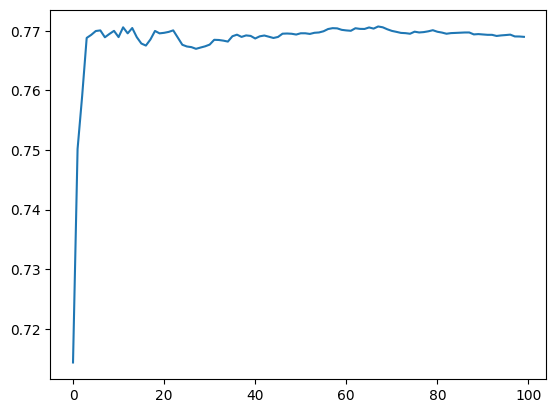

In [201]:
plt.plot([metrics.r2_score(y_valid, np.mean(preds[:i+1], axis=0)) for i in range(100)]);

In [202]:
oobs_5half5 = np.stack([
    RandomForestRegressor(n_jobs=-1, n_estimators=t, oob_score=True, max_depth=5, max_features=0.5, min_samples_leaf=5).fit(X, y).oob_score_ for t in range(5, 150, 5)
])

In [203]:
oobs = np.stack([
    RandomForestRegressor(n_jobs=-1, n_estimators=t, oob_score=True).fit(X, y).oob_score_ for t in range(5, 150, 5)
])

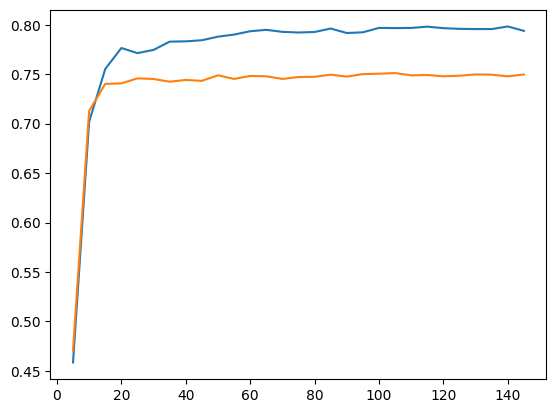

In [204]:
plt.plot(range(5, 150, 5), oobs)
plt.plot(range(5, 150, 5), oobs_5half5)

In [205]:
parameters = {'min_samples_leaf':[1, 3, 5, 10],
              'max_features': ['None', 0.5, 'log2', 'sqrt'],
              'max_depth' : [2, 3, 5, 10, 100]
             }
RF_model = RandomForestRegressor(n_jobs=-1, random_state=42, oob_score=True)
grid_search = GridSearchCV(RF_model, parameters)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print(best_params)

{'max_depth': 100, 'max_features': 0.5, 'min_samples_leaf': 1}


In [212]:
m = RandomForestRegressor(n_jobs=-1, random_state=42, max_depth=100, max_features=0.5, min_samples_leaf=1, oob_score=True)
#m = RandomForestRegressor(n_jobs=-1, random_state=42, max_depth=2, min_samples_leaf=1, oob_score=True)
m.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",100
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [213]:
print_score(m)

{'rmse_train': 0.0522180183879598, 'rmse_valid': 0.13292843740618174, 'r2_train': 0.9707495236756735, 'r2_valid': 0.8192506777792548, 'r2_oob': 0.7883861604780754}


In [214]:
X.dtypes

temperature_2m                 float64
relative_humidity_2m           float64
precipitation                  float64
snowfall                       float64
cloud_cover                    float64
cloud_cover_high               float64
cloud_cover_mid                float64
cloud_cover_low                float64
shortwave_radiation_instant    float64
wind_speed_10m                 float64
wind_direction_10m             float64
wind_speed_80m                 float64
wind_direction_80m             float64
wind_gusts_10m                 float64
angle_of_incidence             float64
zenith                         float64
azimuth                        float64
dtype: object

In [215]:
y

0       0.148554
1       0.461922
2       0.724566
3       0.826882
4       0.863716
          ...   
4208    0.056729
4209    0.132096
4210    0.051808
4211    0.041531
4212    0.006561
Name: generated_power_kw, Length: 4213, dtype: float64

In [216]:
#X_ = denormalize(X, nkeys)
#y_ = denormalize(y, nkeys, y_column)

Text(0.5, 0, 'angle_of_incidence')

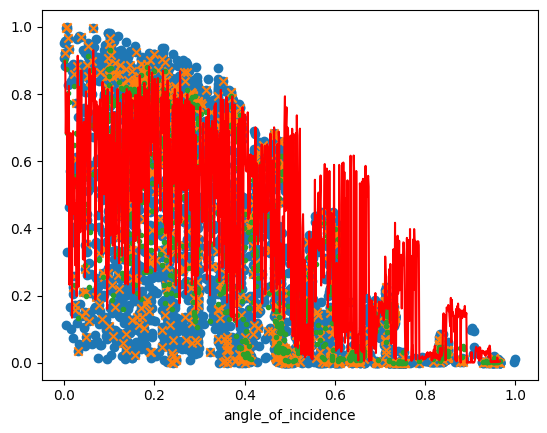

In [218]:
x_column = X.keys()[14]
x = np.linspace(min(X_test[x_column]), max(X_test[x_column]), X_test.shape[0])
df_x = X_test.copy().sort_values(by=x_column)
plt.scatter(X[x_column], y)
plt.scatter(X_test[x_column], y_test, marker = 'x')
plt.scatter(X_test[x_column], m.predict(X_test), marker = '.')
plt.plot(x, m.predict(df_x), color = 'r')
plt.xlabel(x_column)

In [165]:
def train_model(max_depth, min_leaves, max_features):
    if max_features:
        m = RandomForestRegressor(n_jobs=-1, n_estimators=100, oob_score=True, max_depth=max_depth, max_features=max_features, min_samples_leaf=min_leaves)
    else:
        m = RandomForestRegressor(n_jobs=-1, n_estimators=100, oob_score=True, max_depth=max_depth, min_samples_leaf=min_leaves)
    m.fit(X, y)
    oobs = m.oob_score_
    score = m.score(X, y)
    return (oobs - score)**2/oobs**2, oobs

In [166]:
vals = []
min_vals = 1000000
for depth in [2, 3, 5, 10, 100]:
    for min_leaf in [1, 3, 5, 10]:
        for max_f in [None, 0.5, 'log2', 'sqrt']:
            err, oobs = train_model(depth, min_leaf, max_f)
            vals.append([err, oobs])
            if err/oobs < min_vals:
                min_vals = err
                print(f"{err:0.5f} {oobs:0.5f} {depth} {min_leaf} {max_f}")

0.00013 0.48487 2 1 None


In [42]:
vals = np.array(vals)

In [43]:
print(vals)

[[1.41178433e-04 4.85476056e-01]
 [2.36421828e-04 5.38116389e-01]
 [3.22686715e-04 4.87649017e-01]
 [4.99787776e-04 4.43320761e-01]
 [7.83978599e-05 4.84409839e-01]
 [3.33608611e-04 5.38034843e-01]
 [3.77288907e-04 4.70982163e-01]
 [4.87614845e-04 4.62369953e-01]
 [1.18235008e-04 4.91160303e-01]
 [2.43272535e-04 5.38727758e-01]
 [4.45864456e-04 4.70449713e-01]
 [5.31656448e-04 4.37907223e-01]
 [1.05741604e-04 4.84894457e-01]
 [2.39661650e-04 5.44798915e-01]
 [3.79560869e-04 4.61894733e-01]
 [7.87722948e-04 4.57004477e-01]
 [2.54051012e-04 6.04381004e-01]
 [2.72603255e-04 6.48866429e-01]
 [5.03236022e-04 5.97720831e-01]
 [3.74298330e-04 5.95393518e-01]
 [2.89984486e-04 6.05163723e-01]
 [3.55598699e-04 6.51534535e-01]
 [4.79556358e-04 5.91629078e-01]
 [4.80035846e-04 5.93995996e-01]
 [3.53719959e-04 6.06434097e-01]
 [3.95448381e-04 6.40344231e-01]
 [5.12372680e-04 5.82408498e-01]
 [6.53720671e-04 5.76249764e-01]
 [2.80313260e-04 6.06358874e-01]
 [4.18478398e-04 6.40212765e-01]
 [5.613154

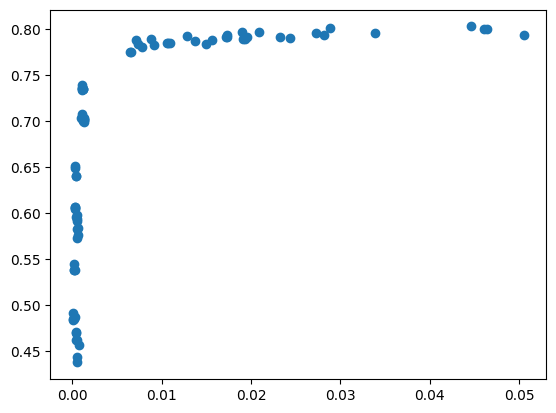

In [47]:
fig = plt.figure()
plt.scatter(vals.T[0], vals.T[1])
plt.show()

In [276]:
m = RandomForestRegressor(n_jobs=-1, n_estimators=100, oob_score=True, max_depth=2, min_samples_leaf=3)
m.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [277]:
m.oob_score_

0.48695597888789444

In [278]:
m.score(X,y)

0.49177877086353017